In [19]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (upload file first in Colab)
df = pd.read_csv('q2_customers.csv')

# View data
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [20]:
from sklearn.preprocessing import StandardScaler

# Apply scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert to DataFrame for viewing
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

print("Scaled Data:")
scaled_df.head()



Scaled Data:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Interpretation:

After applying StandardScaler, all the features have been transformed to a common scale with a mean close to 0 and a standard deviation of 1. This is why we see both positive and negative values in the dataset.

Positive values indicate that the original value is above the average, while negative values indicate values below the average. For example, a higher value in `visits_per_month` or `annual_spend` means that customer is above average in that behavior.

Scaling is important for K-Means clustering because the algorithm relies on distance calculations. If the data is not scaled, features with larger values could dominate the clustering process and lead to incorrect groupings.

By standardizing the data, we ensure that all features contribute equally, resulting in more accurate and meaningful customer segments.

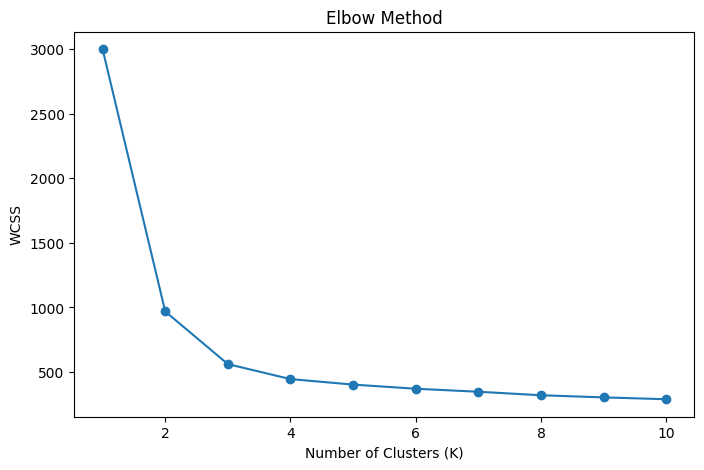

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Calculate WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot Elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()



### Interpretation:

The elbow method graph shows how the Within-Cluster Sum of Squares (WCSS) decreases as the number of clusters (K) increases. Initially, there is a sharp drop in WCSS from K = 1 to K = 3, indicating that adding more clusters significantly improves the grouping.

After K = 3, the decrease in WCSS becomes much more gradual, meaning that adding more clusters does not provide substantial improvement.

This point where the curve starts to flatten is known as the "elbow point". In this case, the elbow appears at K = 3.

Therefore, the optimal number of clusters is chosen as K = 3, as it provides a good balance between minimizing WCSS and avoiding unnecessary complexity.

In [22]:
# optimal K
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit and assign clusters
df['cluster'] = kmeans.fit_predict(scaled_df)

# View data with clusters
df.head()



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [23]:
# Convert centroids to original scale for better understanding
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

print("Cluster Centroids:")
centroids


Cluster Centroids:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation (Business View):

Based on the cluster centroids, we can interpret the customer segments as follows:

**Cluster 0 – Young, Frequent Low-Spenders:**
This group consists of younger customers (average age 25) who visit the store frequently (around 14 visits per month) but have relatively low annual spending (15K) and smaller basket sizes. They also purchase from fewer categories. These customers are highly engaged but spend less per visit, making them ideal targets for upselling and cross-selling strategies.

**Cluster 1 – High-Value, Infrequent Premium Customers:**
This segment includes older customers (average age 57) who have very high annual spending (89K) and large basket sizes. However, they visit less frequently (around 2–3 visits per month) and have long gaps between visits. They also purchase from many categories. These are high-value customers, and businesses should focus on retention strategies, loyalty programs, and personalized offers to keep them engaged.

**Cluster 2 – Mid-Age, Moderate Spenders:**
This group represents middle-aged customers (average age 40) with moderate annual spending (~43K), average visit frequency (8 visits per month), and medium basket sizes. They show balanced behavior across all features and purchase from a moderate number of categories. These customers are stable and can be encouraged to move into the high-value segment through targeted promotions.

In [24]:
from sklearn.decomposition import PCA

# Reduce to 2 components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Create DataFrame
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

# Add cluster labels
pca_df['cluster'] = df['cluster']

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)



Explained Variance Ratio:
[0.83560354 0.05568764]


In [25]:
# PCA loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

print("Feature Loadings:")
loadings



Feature Loadings:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### Interpretation:

The PCA results show how different features contribute to the two principal components (PC1 and PC2).

**PC1 (Principal Component 1):**  
PC1 has strong positive contributions from features like age, annual_spend, basket_size, days_since_last_visit, and num_categories_purchased, while visits_per_month has a negative contribution. This suggests that PC1 captures overall customer value and spending behavior. Customers with higher PC1 scores are likely to be higher spenders, purchase from more categories, and have larger basket sizes, but may visit less frequently.

**PC2 (Principal Component 2):**  
PC2 is strongly influenced by days_since_last_visit, which has a very high positive loading. This indicates that PC2 mainly captures recency behavior, meaning how recently a customer has visited. Customers with higher PC2 values are those who have not visited for a longer time, while lower values indicate more recent engagement.

Overall, PC1 represents customer value and purchasing behavior, while PC2 represents customer recency and engagement patterns.

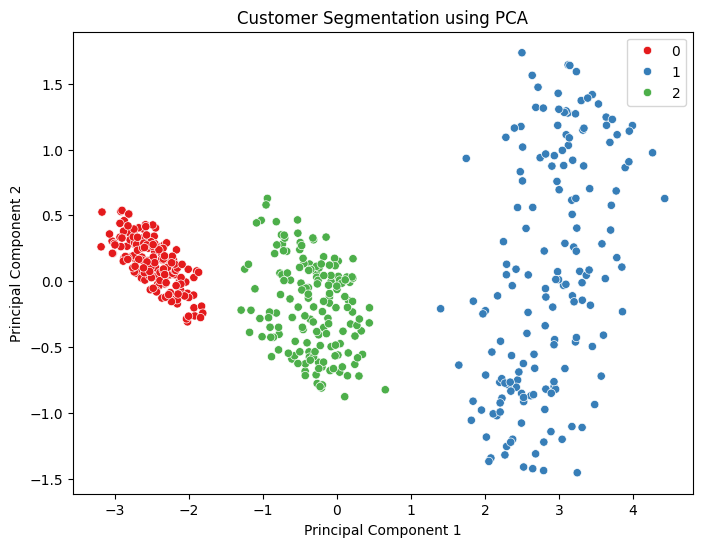

In [26]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.show()

